# Thinkpad dataset — deep dive

**Scope**
- `datasets/flow-2` only (class folders at dataset root)
- Integrity, duration, waveform scalars, CQT-derived spectral / label metrics
- Outliers and within-dataset near-duplicates

**Out of scope**
- Onset / multi-onset analysis
- Cross-dataset comparison (see sibling notebooks under `training/`, `vivo/`)
- Re-running CQT extraction or model training

**Artifacts**
- `datasets/flow-2-dataset-info.pkl` — duration inventory (rebuild only if missing)
- `features/flow-2.npz` — cached CQT `(N, 216, 188)`
- Metrics cache: `datasets/flow-2-sample-metrics.pkl`

In [1]:
from os import path, listdir
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from tqdm.notebook import tqdm
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# --- per-dataset config (this notebook is under notebooks/flow-2/) ---
DATASET = "flow-2"
# feature cache filename for this dataset
FEATURES_NAME = "flow-2.npz"

DATASET_DIR = path.normpath(f"../../datasets/{DATASET}")
SOURCE_PATH = DATASET_DIR
TRAIN_DIR = DATASET_DIR
INVENTORY_PATH = path.normpath(f"../../datasets/{DATASET}-dataset-info.pkl")
FEATURES_PATH = path.normpath(f"../../features/{FEATURES_NAME}")
METRICS_PATH = path.normpath(f"../../datasets/{DATASET}-sample-metrics.pkl")

AUDIO_SAMPLE_RATE = 48_000
CQT_HOP_LENGTH = 512
CQT_BINS_PER_OCTAVE = 36
CQT_OCTAVES = 6
CQT_FMIN = librosa.note_to_hz("C1")
CQT_FEATURE_FRAMES = round(2.0 * AUDIO_SAMPLE_RATE / CQT_HOP_LENGTH)  # 188
CQT_FLOOR_DB = -80.0

BOXPROPS = dict(color="#01696f", linewidth=1.4)
WHISKERPROPS = dict(color="#01696f", linewidth=1.2, linestyle="--")
MEDIANPROPS = dict(color="#da7101", linewidth=2)
FLIERPROPS = dict(
    marker="o", markerfacecolor="#a12c7b", markersize=4, linestyle="none", alpha=0.6
)

display(pd.DataFrame([
    {"key": "dataset", "value": DATASET},
    {"key": "dataset_dir", "value": DATASET_DIR},
    {"key": "features", "value": FEATURES_PATH},
    {"key": "metrics_cache", "value": METRICS_PATH},
    {"key": "cqt_feature_frames (2s)", "value": CQT_FEATURE_FRAMES},
    {"key": "audio_sample_rate", "value": AUDIO_SAMPLE_RATE},
]))

,key,value
0,dataset,flow-2
1,dataset_dir,../../datasets/flow-2
2,features,../../features/flow-2.npz
3,metrics_cache,../../datasets/flow-2-sample-metrics.pkl
4,cqt_feature_frames (2s),188
5,audio_sample_rate,48000


## 1. Inventory & duration

Load the existing duration inventory if present; otherwise scan training audio once.
Parse class names into root / quality / octave and keep **training only**.

In [2]:
def scan_dataset_inventory(source_path: str) -> pd.DataFrame:
    """Walk dataset/{class}/* audio files (sorted) and record durations."""
    records = []
    dataset_type = path.basename(source_path)
    for class_name in tqdm(sorted(listdir(source_path)), desc=f"  {dataset_type}"):
        class_path = path.join(source_path, class_name)
        if not path.isdir(class_path):
            continue
        for audio_file in sorted(listdir(class_path)):
            audio_path = path.join(class_path, audio_file)
            if not path.isfile(audio_path):
                continue
            # skip non-audio keepers
            if audio_file.startswith(".") or not audio_file.lower().endswith(
                (".ogg", ".wav", ".flac", ".mp3")
            ):
                continue
            try:
                duration = librosa.get_duration(path=audio_path)
                records.append(
                    {
                        "dataset_type": dataset_type,
                        "class_name": class_name,
                        "filename": audio_file,
                        "duration_s": duration,
                    }
                )
            except Exception as e:
                display(Markdown(f"**WARN** Could not read `{audio_path}`: {e}"))
    return pd.DataFrame(records)


def list_audio_keys(source_path: str) -> set:
    """Set of class/filename keys currently on disk (sorted walk, audio only)."""
    keys = set()
    for class_name in sorted(listdir(source_path)):
        class_path = path.join(source_path, class_name)
        if not path.isdir(class_path):
            continue
        for audio_file in sorted(listdir(class_path)):
            if audio_file.startswith("."):
                continue
            if not audio_file.lower().endswith((".ogg", ".wav", ".flac", ".mp3")):
                continue
            if path.isfile(path.join(class_path, audio_file)):
                keys.add(f"{class_name}/{audio_file}")
    return keys


def inventory_is_current(inventory: pd.DataFrame, source_path: str, dataset_name: str) -> bool:
    """True only if inventory is a clean, single-dataset mirror of disk."""
    if inventory is None or len(inventory) == 0:
        return False
    required = {"dataset_type", "class_name", "filename", "duration_s"}
    if not required.issubset(set(inventory.columns)):
        return False
    # Must not mix other dataset_types (e.g. legacy evaluation rows)
    types = set(inventory["dataset_type"].astype(str).unique())
    if types != {dataset_name}:
        return False
    disk_keys = list_audio_keys(source_path)
    inv_keys = set(
        inventory["class_name"].astype(str) + "/" + inventory["filename"].astype(str)
    )
    return disk_keys == inv_keys


def parse_class_name(name: str) -> pd.Series:
    m = re.match(r"^([A-G]#?)_(major|minor|diminished)_(\d+)$", name)
    if not m:
        return pd.Series({"root": None, "quality": None, "octave": None})
    return pd.Series(
        {"root": m.group(1), "quality": m.group(2), "octave": int(m.group(3))}
    )


def file_index(filename: str):
    m = re.search(r"-(\d+)\.(ogg|wav)$", filename, re.I)
    return int(m.group(1)) if m else np.nan


inventory = None
if path.exists(INVENTORY_PATH):
    try:
        inventory = pd.read_pickle(INVENTORY_PATH)
    except Exception as e:
        display(Markdown(
            f"**WARN** Could not load inventory `{INVENTORY_PATH}` "
            f"({type(e).__name__}: {e}). Rescanning."
        ))
        inventory = None

if inventory is not None and inventory_is_current(inventory, DATASET_DIR, DATASET):
    display(Markdown(
        f"Loaded current inventory from `{INVENTORY_PATH}` (**{len(inventory)}** rows)"
    ))
else:
    if inventory is not None:
        display(Markdown(
            f"**WARN** Inventory at `{INVENTORY_PATH}` is stale or non-standard "
            f"(rows={len(inventory)}, types={sorted(inventory['dataset_type'].astype(str).unique()) if 'dataset_type' in inventory.columns else 'n/a'}). "
            f"Rescanning `{DATASET_DIR}` for reproducibility."
        ))
    inventory = scan_dataset_inventory(DATASET_DIR)
    inventory.to_pickle(INVENTORY_PATH)
    display(Markdown(
        f"Scanned and saved inventory to `{INVENTORY_PATH}` (**{len(inventory)}** rows)"
    ))

# Single-dataset inventory after validation: all rows belong to DATASET
df = inventory.reset_index(drop=True)
meta = df["class_name"].apply(parse_class_name)
df = pd.concat([df, meta], axis=1)
df["file_idx"] = df["filename"].map(file_index)
df["audio_path"] = [
    path.join(DATASET_DIR, c, f) for c, f in zip(df["class_name"], df["filename"])
]

summary = pd.DataFrame([
    {"metric": "rows", "value": len(df)},
    {"metric": "n_classes", "value": df["class_name"].nunique()},
    {"metric": "parse_failures", "value": int(df["root"].isna().sum())},
    {"metric": "per_class_min", "value": int(df.groupby("class_name").size().min()) if len(df) else 0},
    {"metric": "per_class_max", "value": int(df.groupby("class_name").size().max()) if len(df) else 0},
    {"metric": "dataset_types", "value": sorted(df["dataset_type"].astype(str).unique())},
])
display(Markdown(f"### {DATASET} inventory summary"))
display(summary)
display(Markdown("### Sample rows"))
display(df.head(10))

  flow-2:   0%|          | 0/36 [00:00<?, ?it/s]

Scanned and saved inventory to `../../datasets/flow-2-dataset-info.pkl` (**1440** rows)

### flow-2 inventory summary

,metric,value
0,rows,1440
1,n_classes,36
2,parse_failures,0
3,per_class_min,40
4,per_class_max,40
5,dataset_types,[flow-2]


### Sample rows

,dataset_type,class_name,filename,duration_s,root,quality,octave,file_idx,audio_path
0,flow-2,A#_diminished_4,A#_diminished_4-1.wav,2.3400,A#,diminished,4,1,../../datasets/flow-2/A#_diminished_4/A#_dimin...
1,flow-2,A#_diminished_4,A#_diminished_4-10.wav,2.4000,A#,diminished,4,10,../../datasets/flow-2/A#_diminished_4/A#_dimin...
2,flow-2,A#_diminished_4,A#_diminished_4-11.wav,2.4000,A#,diminished,4,11,../../datasets/flow-2/A#_diminished_4/A#_dimin...
3,flow-2,A#_diminished_4,A#_diminished_4-12.wav,2.2800,A#,diminished,4,12,../../datasets/flow-2/A#_diminished_4/A#_dimin...
4,flow-2,A#_diminished_4,A#_diminished_4-13.wav,2.3400,A#,diminished,4,13,../../datasets/flow-2/A#_diminished_4/A#_dimin...
5,flow-2,A#_diminished_4,A#_diminished_4-14.wav,2.3400,A#,diminished,4,14,../../datasets/flow-2/A#_diminished_4/A#_dimin...
6,flow-2,A#_diminished_4,A#_diminished_4-15.wav,2.4000,A#,diminished,4,15,../../datasets/flow-2/A#_diminished_4/A#_dimin...
7,flow-2,A#_diminished_4,A#_diminished_4-16.wav,2.4600,A#,diminished,4,16,../../datasets/flow-2/A#_diminished_4/A#_dimin...
8,flow-2,A#_diminished_4,A#_diminished_4-17.wav,2.4600,A#,diminished,4,17,../../datasets/flow-2/A#_diminished_4/A#_dimin...
9,flow-2,A#_diminished_4,A#_diminished_4-18.wav,2.3400,A#,diminished,4,18,../../datasets/flow-2/A#_diminished_4/A#_dimin...


In [3]:
# --- Inventory integrity ---
class_counts = df.groupby("class_name").size().rename("n").reset_index()
quality_counts = df["quality"].value_counts().rename_axis("quality").reset_index(name="n")
root_counts = df["root"].value_counts().sort_index().rename_axis("root").reset_index(name="n")

idx_issues = []
for cls, g in df.groupby("class_name"):
    idxs = sorted(g.file_idx.dropna().astype(int).tolist())
    expected = list(range(1, len(idxs) + 1))
    if idxs != expected:
        missing = sorted(set(expected) - set(idxs))
        dups = [i for i, c in pd.Series(idxs).value_counts().items() if c > 1]
        idx_issues.append({"class_name": cls, "missing": missing, "dups": dups})

hygiene = pd.DataFrame([
    {"check": "file_index_issues", "value": len(idx_issues)},
    {"check": "filename_matches_class_prefix", "value": bool(df.apply(lambda r: r.filename.startswith(r.class_name), axis=1).all())},
    {"check": "all_audio_ext", "value": bool(df.filename.str.lower().str.endswith((".ogg", ".wav")).all())},
    {"check": "octaves", "value": sorted(df.octave.dropna().unique().tolist())},
    {"check": "roots", "value": sorted(df.root.dropna().unique().tolist())},
    {"check": "qualities", "value": sorted(df.quality.dropna().unique().tolist())},
    {"check": "unique_per_class_counts", "value": class_counts["n"].unique().tolist()},
])

display(Markdown("### Hygiene checks"))
display(hygiene)
display(Markdown("### Counts by quality"))
display(quality_counts)
display(Markdown("### Counts by root"))
display(root_counts)

# --- Duration summary ---
dur_desc = df["duration_s"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame("duration_s")
dur_hist = (
    df["duration_s"].round(6).value_counts().sort_index()
    .rename_axis("duration_s").reset_index(name="count")
)
dur_hist["share"] = dur_hist["count"] / dur_hist["count"].sum()

dur_vs_window = pd.DataFrame([
    {"check": "shorter_than_2.0s", "n": int((df.duration_s < 2.0).sum())},
    {"check": "exactly_2.0s", "n": int((df.duration_s == 2.0).sum())},
    {"check": "between_2.0_and_2.5s", "n": int(((df.duration_s >= 2.0) & (df.duration_s <= 2.5)).sum())},
    {"check": "longer_than_2.5s", "n": int((df.duration_s > 2.5).sum())},
    {"check": "unique_durations", "n": int(df.duration_s.nunique())},
])

cls_dur = (
    df.groupby("class_name")["duration_s"]
    .agg(n="count", min="min", mean="mean", median="median", max="max", std="std")
    .round(4)
    .sort_values("mean")
)
qual_dur = df.groupby("quality")["duration_s"].agg(["count", "min", "mean", "median", "max", "std"]).round(4)

display(Markdown("### Duration describe"))
display(dur_desc)
display(Markdown("### Duration histogram (discrete)"))
display(dur_hist)
display(Markdown("### Duration vs 2.0s model window"))
display(dur_vs_window)
display(Markdown("### Shortest / longest samples"))
display(df.nsmallest(5, "duration_s")[["class_name", "filename", "duration_s"]])
display(df.nlargest(5, "duration_s")[["class_name", "filename", "duration_s"]])
display(Markdown("### Duration by quality"))
display(qual_dur)
display(Markdown("### Class mean duration (shortest → longest)"))
display(cls_dur)

### Hygiene checks

,check,value
0,file_index_issues,0
1,filename_matches_class_prefix,True
2,all_audio_ext,True
3,octaves,[4]
4,roots,"[A, A#, B, C, C#, D, D#, E, F, F#, G, G#]"
5,qualities,"[diminished, major, minor]"
6,unique_per_class_counts,[40]


### Counts by quality

,quality,n
0,diminished,480
1,major,480
2,minor,480


### Counts by root

...

,class_name,filename,duration_s
601,D#_diminished_4,D#_diminished_4-10.wav,2.7600
62,A#_major_4,A#_major_4-3.wav,2.7000
118,A#_minor_4,A#_minor_4-8.wav,2.7000
175,A_major_4,A_major_4-23.wav,2.7000
221,A_minor_4,A_minor_4-29.wav,2.7000


### Duration by quality

,count,min,mean,median,max,std
quality,,,,,,
diminished,480,2.1600,2.4339,2.4000,2.7600,0.1046
major,480,2.1600,2.4438,2.4600,2.7000,0.1073
minor,480,2.1600,2.4424,2.4600,2.7000,0.1083


### Class mean duration (shortest → longest)

,n,min,mean,median,max,std
class_name,,,,,,
C_minor_4,40,2.2200,2.3940,2.4000,2.5800,0.0824
A#_diminished_4,40,2.2200,2.4120,2.4000,2.6400,0.0953
F_diminished_4,40,2.2200,2.4150,2.4000,2.7000,0.1143
A#_minor_4,40,2.1600,2.4225,2.4000,2.7000,0.1158
A_diminished_4,40,2.2200,2.4225,2.4000,2.6400,0.1032
A#_major_4,40,2.2800,2.4225,2.4000,2.7000,0.1084
F#_diminished_4,40,2.2200,2.4240,2.4000,2.6400,0.1077
B_diminished_4,40,2.1600,2.4240,2.4000,2.6400,0.1159
E_diminished_4,40,2.2200,2.4255,2.4000,2.5800,0.0879


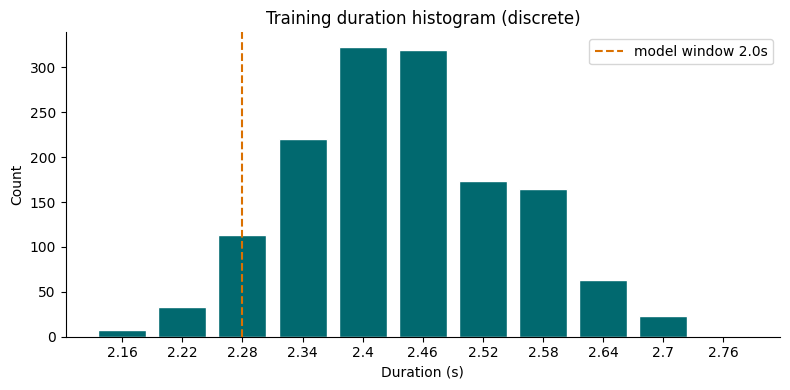

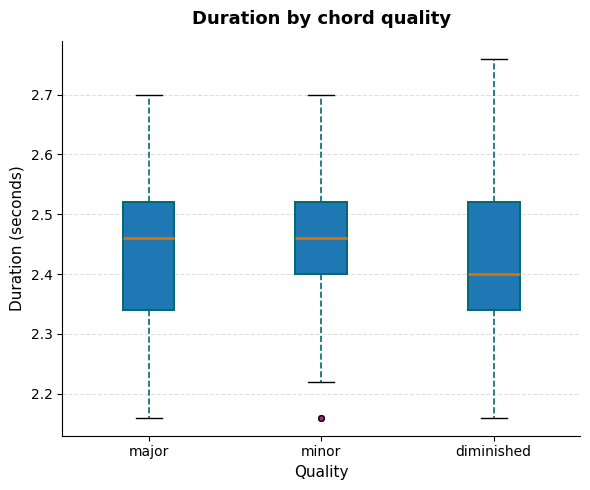

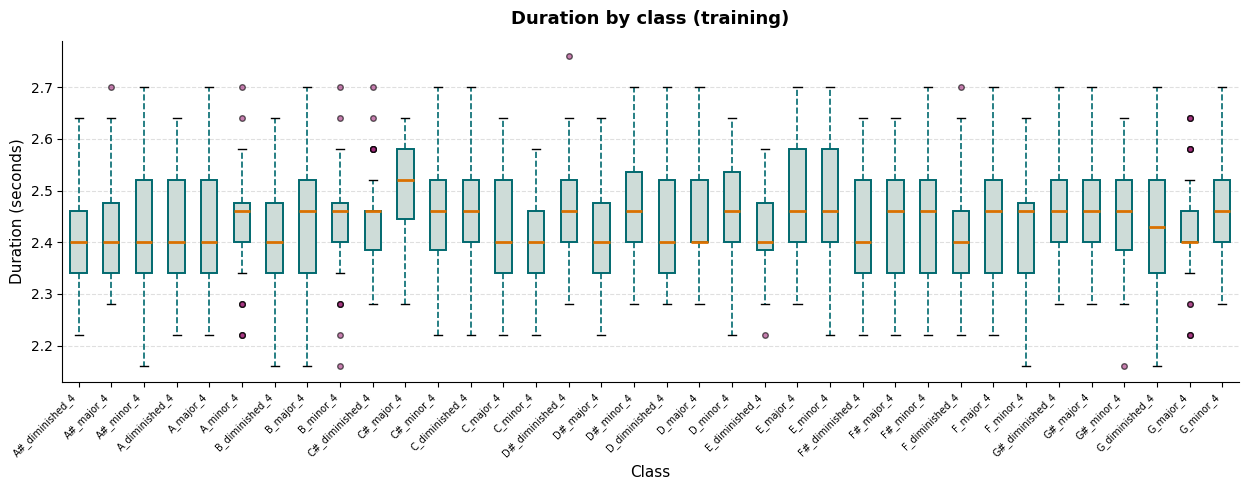

In [4]:
def _base_fig(n_groups, title, xlabel, ylabel="Duration (seconds)"):
    fig, ax = plt.subplots(figsize=(max(6, n_groups * 0.35), 5))
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    return fig, ax


# Duration histogram
fig, ax = plt.subplots(figsize=(8, 4))
vals = sorted(df["duration_s"].round(6).unique())
counts = df["duration_s"].round(6).value_counts().reindex(vals).fillna(0)
ax.bar([str(v) for v in vals], counts.values, color="#01696f", edgecolor="white")
ax.axvline(2.0, color="#da7101", linestyle="--", linewidth=1.5, label="model window 2.0s")
ax.set_title("Training duration histogram (discrete)")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Count")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Duration by quality
qualities = ["major", "minor", "diminished"]
data_q = [df.loc[df.quality == q, "duration_s"].values for q in qualities]
fig, ax = _base_fig(len(qualities), "Duration by chord quality", "Quality")
ax.boxplot(
    data_q,
    tick_labels=qualities,
    boxprops=BOXPROPS,
    whiskerprops=WHISKERPROPS,
    medianprops=MEDIANPROPS,
    flierprops=FLIERPROPS,
    patch_artist=True,
)
plt.tight_layout()
plt.show()

# Duration by class (compact)
class_names = sorted(df["class_name"].unique())
data_c = [df.loc[df.class_name == c, "duration_s"].values for c in class_names]
fig, ax = _base_fig(len(class_names), "Duration by class (training)", "Class")
ax.boxplot(
    data_c,
    tick_labels=class_names,
    boxprops={**BOXPROPS, "facecolor": "#cedcd8"},
    whiskerprops=WHISKERPROPS,
    medianprops=MEDIANPROPS,
    flierprops=FLIERPROPS,
    patch_artist=True,
)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

## 2. Waveform integrity (raw audio)

Lightweight pass over every dataset audio file — **no CQT recompute**.
Scalars catch clipping, silence, DC offset, level problems, and read failures.
Results are cached in the metrics pkl under the `wave_*` columns (merged later).

In [5]:
def waveform_metrics(audio_path: str, target_sr: int = AUDIO_SAMPLE_RATE) -> dict:
    """Cheap per-file waveform scalars (librosa; soundfile may not decode Ogg audio)."""
    try:
        y, sr = librosa.load(audio_path, sr=target_sr, mono=True)
        y = np.asarray(y, dtype=np.float64)
        n = len(y)
        if n == 0:
            return {"wave_ok": False, "wave_error": "empty"}

        peak = float(np.max(np.abs(y)))
        rms = float(np.sqrt(np.mean(y ** 2)))
        dc = float(np.mean(y))
        thr = max(1e-4, 0.01 * peak) if peak > 0 else 1e-4
        silent = np.abs(y) < thr
        silence_ratio = float(silent.mean())

        if (~silent).any():
            first = int(np.argmax(~silent))
            last = int(n - 1 - np.argmax(~silent[::-1]))
            lead_s = first / sr
            trail_s = (n - 1 - last) / sr
            active_s = (last - first + 1) / sr
        else:
            lead_s = trail_s = n / sr
            active_s = 0.0

        clip_frac = float((np.abs(y) >= 0.99).mean())
        zcr = float(((y[:-1] * y[1:]) < 0).mean()) if n > 1 else 0.0
        crest = peak / rms if rms > 1e-12 else np.inf

        return {
            "wave_ok": True,
            "wave_error": None,
            "wave_sr": int(sr),
            "wave_channels": 1,
            "wave_n_samples": int(n),
            "wave_duration_s": n / sr,
            "wave_peak": peak,
            "wave_peak_db": float(20 * np.log10(peak + 1e-12)),
            "wave_rms": rms,
            "wave_rms_db": float(20 * np.log10(rms + 1e-12)),
            "wave_crest": float(crest) if np.isfinite(crest) else 1e6,
            "wave_dc": dc,
            "wave_dc_abs": abs(dc),
            "wave_silence_ratio": silence_ratio,
            "wave_lead_silence_s": float(lead_s),
            "wave_trail_silence_s": float(trail_s),
            "wave_active_s": float(active_s),
            "wave_clip_frac": clip_frac,
            "wave_zcr": zcr,
        }
    except Exception as e:
        return {"wave_ok": False, "wave_error": str(e)}


# Only reuse cache if prior run actually succeeded (and pickle is loadable)
wave_cols_prefix = "wave_"
reuse_wave = False
if path.exists(METRICS_PATH):
    try:
        cached = pd.read_pickle(METRICS_PATH)
    except Exception as e:
        display(Markdown(f"**WARN** Could not load metrics cache `{METRICS_PATH}` ({type(e).__name__}: {e}). Recomputing."))
        cached = None
    if cached is not None and (
        len(cached) == len(df)
        and "filename" in cached.columns
        and cached["filename"].tolist() == df["filename"].tolist()
        and cached["class_name"].tolist() == df["class_name"].tolist()
        and "wave_ok" in cached.columns
        and bool(cached["wave_ok"].all())
    ):
        wave_df = cached[
            [c for c in cached.columns if c.startswith(wave_cols_prefix) or c in ("class_name", "filename")]
        ].copy()
        reuse_wave = True
        display(Markdown(f"Reused waveform metrics from cache (**{len(wave_df)}** rows)"))

if not reuse_wave:
    rows = []
    for p in tqdm(df["audio_path"].tolist(), desc="Waveform metrics"):
        rows.append(waveform_metrics(p))
    wave_df = pd.DataFrame(rows)
    wave_df.insert(0, "filename", df["filename"].values)
    wave_df.insert(0, "class_name", df["class_name"].values)
    display(Markdown(f"Computed waveform metrics for **{len(wave_df)}** files"))

status = pd.DataFrame([
    {"metric": "wave_ok", "n": int(wave_df["wave_ok"].sum())},
    {"metric": "wave_fail", "n": int((~wave_df["wave_ok"]).sum())},
    {"metric": "total", "n": len(wave_df)},
])
display(status)
if (~wave_df["wave_ok"]).any():
    display(Markdown("### Failed reads"))
    display(wave_df.loc[~wave_df["wave_ok"], ["class_name", "filename", "wave_error"]].head(20))

Waveform metrics:   0%|          | 0/1440 [00:00<?, ?it/s]

Computed waveform metrics for **1440** files

,metric,n
0,wave_ok,1440
1,wave_fail,0
2,total,1440


### Waveform level stats

,mean,std,min,p01,median,p99,max
wave_peak,0.4893,0.0799,0.2917,0.3495,0.4817,0.6914,0.9820
wave_peak_db,-6.3211,1.3871,-10.7026,-9.1299,-6.3437,-3.2057,-0.1574
wave_rms_db,-22.6188,1.4821,-26.4398,-26.0692,-22.3489,-20.0683,-17.6742
wave_crest,6.5751,0.7798,4.6827,4.9883,6.5076,8.5095,9.7461
wave_dc_abs,0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,0.0003
wave_silence_ratio,0.1042,0.0194,0.0586,0.0661,0.1034,0.1553,0.1797
wave_lead_silence_s,0.0070,0.0015,0.0055,0.0065,0.0066,0.0130,0.0265
wave_trail_silence_s,0.0001,0.0003,0.0000,0.0000,0.0000,0.0012,0.0045
wave_active_s,2.4329,0.1068,2.1530,2.2125,2.4521,2.6932,2.7526
wave_clip_frac,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### Sample rates / channels

,sr,n
0,48000,1440


,channels,n
0,1,1440


### Waveform flag rates

,flag,n,rate
0,flag_near_clip,1,0.0007
1,flag_read_fail,0,0.0000
2,flag_clip,0,0.0000
3,flag_too_quiet,0,0.0000
4,flag_too_loud,0,0.0000
5,flag_dc,0,0.0000
6,flag_mostly_silent,0,0.0000
7,flag_long_lead_silence,0,0.0000
8,flag_short_active,0,0.0000
9,flag_sr_mismatch,0,0.0000


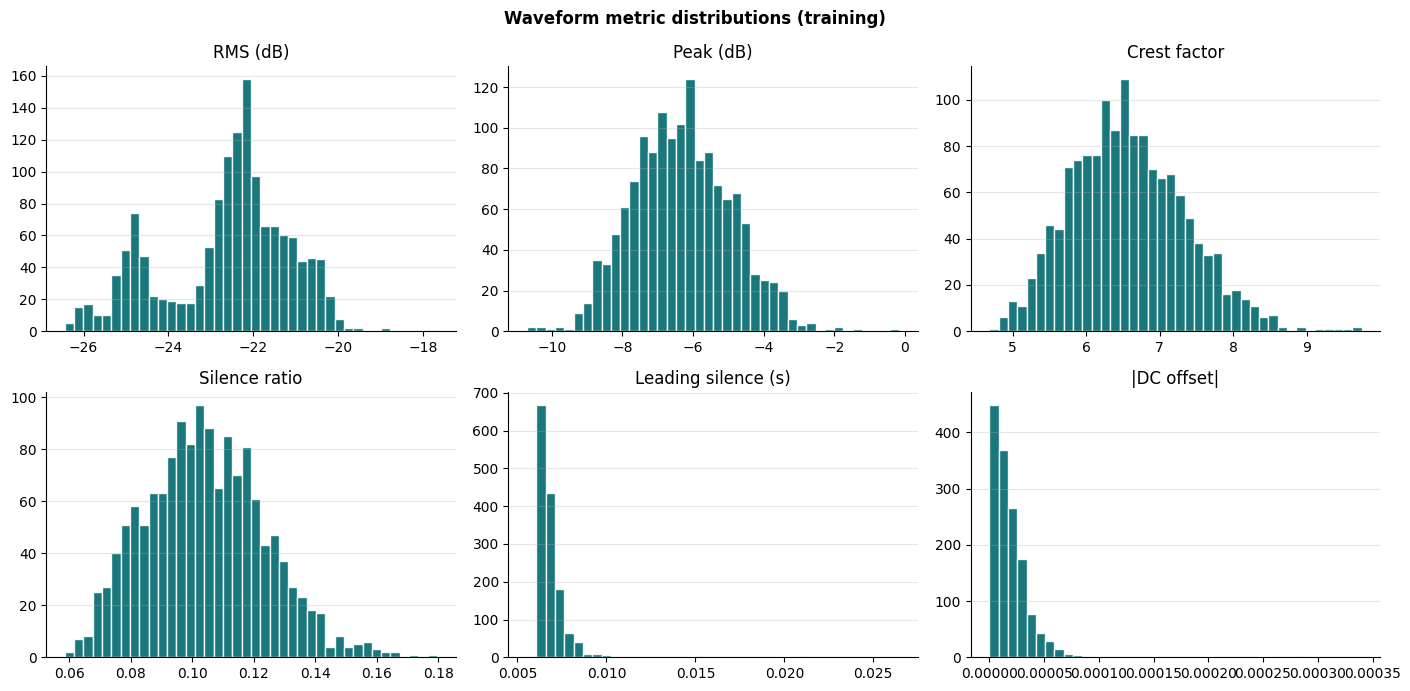

### Extreme samples

**Lowest RMS (dB)**

,class_name,filename,wave_rms_db
0,G#_major_4,G#_major_4-17.wav,-26.4399
1,G#_major_4,G#_major_4-3.wav,-26.4271
2,G#_major_4,G#_major_4-19.wav,-26.3418
3,G#_major_4,G#_major_4-34.wav,-26.3016
4,G#_major_4,G#_major_4-10.wav,-26.2378


**Highest peak**

,class_name,filename,wave_peak
0,E_diminished_4,E_diminished_4-4.wav,0.9820
1,G_major_4,G_major_4-2.wav,0.8652
2,C_major_4,C_major_4-29.wav,0.8023
3,C#_diminished_4,C#_diminished_4-6.wav,0.8013
4,B_minor_4,B_minor_4-9.wav,0.7898


...

,class_name,filename,wave_silence_ratio
0,G#_major_4,G#_major_4-17.wav,0.1796
1,A_diminished_4,A_diminished_4-14.wav,0.1707
2,A_minor_4,A_minor_4-33.wav,0.1669
3,G#_major_4,G#_major_4-35.wav,0.1657
4,G#_major_4,G#_major_4-9.wav,0.1633


**Highest |DC|**

,class_name,filename,wave_dc_abs
0,A_diminished_4,A_diminished_4-13.wav,0.0003
1,E_diminished_4,E_diminished_4-4.wav,0.0003
2,G_major_4,G_major_4-2.wav,0.0003
3,A#_diminished_4,A#_diminished_4-29.wav,0.0002
4,A#_diminished_4,A#_diminished_4-26.wav,0.0002


**Longest lead silence**

,class_name,filename,wave_lead_silence_s
0,G_minor_4,G_minor_4-1.wav,0.0265
1,C#_major_4,C#_major_4-1.wav,0.0241
2,F_diminished_4,F_diminished_4-1.wav,0.0227
3,B_minor_4,B_minor_4-1.wav,0.0220
4,C#_diminished_4,C#_diminished_4-1.wav,0.0213


In [6]:
# Waveform summary + flag rates
w = wave_df[wave_df["wave_ok"]].copy()
wave_cols = [
    "wave_peak", "wave_peak_db", "wave_rms_db", "wave_crest",
    "wave_dc_abs", "wave_silence_ratio", "wave_lead_silence_s",
    "wave_trail_silence_s", "wave_active_s", "wave_clip_frac", "wave_zcr",
]
wave_stats = w[wave_cols].agg(["mean", "std", "min", lambda s: s.quantile(0.01), "median", lambda s: s.quantile(0.99), "max"]).T
wave_stats.columns = ["mean", "std", "min", "p01", "median", "p99", "max"]

display(Markdown("### Waveform level stats"))
display(wave_stats.round(5))

display(Markdown("### Sample rates / channels"))
display(w["wave_sr"].value_counts().rename_axis("sr").reset_index(name="n"))
display(w["wave_channels"].value_counts().rename_axis("channels").reset_index(name="n"))

# Integrity flags (tunable thresholds)
flags = pd.DataFrame({
    "class_name": wave_df["class_name"],
    "filename": wave_df["filename"],
})
flags["flag_read_fail"] = ~wave_df["wave_ok"]
flags["flag_clip"] = wave_df["wave_clip_frac"].fillna(0) > 0.001
flags["flag_near_clip"] = wave_df["wave_peak"].fillna(0) >= 0.95
flags["flag_too_quiet"] = wave_df["wave_rms_db"].fillna(-999) < -40
flags["flag_too_loud"] = wave_df["wave_rms_db"].fillna(-999) > -6
flags["flag_dc"] = wave_df["wave_dc_abs"].fillna(0) > 0.02
flags["flag_mostly_silent"] = wave_df["wave_silence_ratio"].fillna(0) > 0.5
flags["flag_long_lead_silence"] = wave_df["wave_lead_silence_s"].fillna(0) > 0.5
flags["flag_short_active"] = wave_df["wave_active_s"].fillna(0) < 1.0
flags["flag_sr_mismatch"] = wave_df["wave_sr"].fillna(0) != AUDIO_SAMPLE_RATE

flag_cols = [c for c in flags.columns if c.startswith("flag_")]
flag_rates = (
    flags[flag_cols].sum().rename("n").to_frame()
    .assign(rate=lambda x: x["n"] / len(flags))
    .sort_values("n", ascending=False)
    .reset_index(names="flag")
)
display(Markdown("### Waveform flag rates"))
display(flag_rates)

# Plots
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
plot_specs = [
    ("wave_rms_db", "RMS (dB)"),
    ("wave_peak_db", "Peak (dB)"),
    ("wave_crest", "Crest factor"),
    ("wave_silence_ratio", "Silence ratio"),
    ("wave_lead_silence_s", "Leading silence (s)"),
    ("wave_dc_abs", "|DC offset|"),
]
for ax, (col, title) in zip(axes.ravel(), plot_specs):
    ax.hist(w[col], bins=40, color="#01696f", edgecolor="white", alpha=0.9)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Waveform metric distributions (training)", fontweight="bold")
plt.tight_layout()
plt.show()

# Extremes
def extremes_table(col, n=5, ascending=True):
    sub = w.nsmallest(n, col) if ascending else w.nlargest(n, col)
    return sub[["class_name", "filename", col]].reset_index(drop=True)

display(Markdown("### Extreme samples"))
display(Markdown("**Lowest RMS (dB)**"))
display(extremes_table("wave_rms_db", ascending=True))
display(Markdown("**Highest peak**"))
display(extremes_table("wave_peak", ascending=False))
display(Markdown("**Highest silence ratio**"))
display(extremes_table("wave_silence_ratio", ascending=False))
display(Markdown("**Highest |DC|**"))
display(extremes_table("wave_dc_abs", ascending=False))
display(Markdown("**Longest lead silence**"))
display(extremes_table("wave_lead_silence_s", ascending=False))

## 3. CQT spectral metrics (from cached NPZ)

Uses the dataset CQT cache at `FEATURES_PATH` (extract with `cqt-extraction.ipynb` if missing).
No re-extraction. Metrics: energy, dynamic range, band energy (C3–C5 vs out-of-band),
chroma entropy, and **chord-tone purity** vs the file label (theory template check).

In [7]:
NOTE_TO_PC = {
    "C": 0, "C#": 1, "D": 2, "D#": 3, "E": 4, "F": 5,
    "F#": 6, "G": 7, "G#": 8, "A": 9, "A#": 10, "B": 11,
}
QUALITY_INTERVALS = {
    "major": (0, 4, 7),
    "minor": (0, 3, 7),
    "diminished": (0, 3, 6),
}


def chord_pitch_classes(root: str, quality: str):
    r = NOTE_TO_PC[root]
    return {(r + i) % 12 for i in QUALITY_INTERVALS[quality]}


def compute_cqt_metrics(features: np.ndarray, labels: np.ndarray, meta_df: pd.DataFrame) -> pd.DataFrame:
    """Vectorized per-sample stats on CQT dB tensors (N, bins, frames)."""
    N, n_bins, n_frames = features.shape
    assert N == len(meta_df)

    power = np.power(10.0, features / 10.0)  # (N, B, T)

    mean_db = features.mean(axis=(1, 2))
    std_db = features.std(axis=(1, 2))
    max_db = features.max(axis=(1, 2))
    min_db = features.min(axis=(1, 2))

    frame_mean = features.mean(axis=1)  # (N, T)
    frame_power = power.mean(axis=1)  # (N, T)
    total_power = frame_power.sum(axis=1) + 1e-12

    mid = n_frames // 2
    early_power_frac = frame_power[:, :mid].sum(axis=1) / total_power
    late_power_frac = frame_power[:, mid:].sum(axis=1) / total_power

    near_floor = (frame_mean <= (CQT_FLOOR_DB + 5)).mean(axis=1)
    frame_dyn = frame_mean.max(axis=1) - frame_mean.min(axis=1)

    bin_freqs = librosa.cqt_frequencies(
        n_bins=n_bins, fmin=CQT_FMIN, bins_per_octave=CQT_BINS_PER_OCTAVE
    )
    bin_midi = librosa.hz_to_midi(bin_freqs)
    c3, c5 = librosa.note_to_midi("C3"), librosa.note_to_midi("C5")
    band_mask = (bin_midi >= c3) & (bin_midi <= c5)
    low_mask = bin_midi < c3
    high_mask = bin_midi > c5

    bin_power = power.mean(axis=2)  # (N, B)
    low_e = bin_power[:, low_mask].sum(axis=1)
    band_e = bin_power[:, band_mask].sum(axis=1)
    high_e = bin_power[:, high_mask].sum(axis=1)
    tot_e = low_e + band_e + high_e + 1e-12

    bins_per_note = CQT_BINS_PER_OCTAVE // 12
    pc_index = (np.arange(n_bins) // bins_per_note) % 12
    chroma = np.zeros((N, 12), dtype=np.float64)
    for pc in range(12):
        chroma[:, pc] = bin_power[:, pc_index == pc].sum(axis=1)
    chroma_sum = chroma.sum(axis=1, keepdims=True) + 1e-12
    chroma_n = chroma / chroma_sum
    chroma_entropy = -(chroma_n * np.log(chroma_n + 1e-12)).sum(axis=1) / np.log(12)
    top1_frac = chroma_n.max(axis=1)
    top3_frac = np.sort(chroma_n, axis=1)[:, -3:].sum(axis=1)

    roots = meta_df["root"].to_numpy()
    quals = meta_df["quality"].to_numpy()
    purity = np.empty(N, dtype=np.float64)
    root_frac = np.empty(N, dtype=np.float64)
    est_root = np.empty(N, dtype=np.int32)
    template_best = np.empty(N, dtype=object)

    templates = {
        "major": np.array([0, 4, 7]),
        "minor": np.array([0, 3, 7]),
        "diminished": np.array([0, 3, 6]),
    }

    for i in range(N):
        pcs = chord_pitch_classes(roots[i], quals[i])
        purity[i] = chroma_n[i, list(pcs)].sum()
        root_pc = NOTE_TO_PC[roots[i]]
        root_frac[i] = chroma_n[i, root_pc]
        est_root[i] = int(np.argmax(chroma_n[i]))

        scores = {}
        for qname, iv in templates.items():
            pcs_q = (est_root[i] + iv) % 12
            scores[qname] = float(chroma_n[i, pcs_q].sum())
        template_best[i] = max(scores, key=scores.get)

    root_match = est_root == np.array([NOTE_TO_PC[r] for r in roots])
    centroid_hz = (bin_power * bin_freqs[None, :]).sum(axis=1) / (bin_power.sum(axis=1) + 1e-12)

    return pd.DataFrame(
        {
            "class_name": meta_df["class_name"].values,
            "filename": meta_df["filename"].values,
            "cqt_mean_db": mean_db,
            "cqt_std_db": std_db,
            "cqt_max_db": max_db,
            "cqt_min_db": min_db,
            "cqt_frame_dyn_db": frame_dyn,
            "cqt_near_floor_frac": near_floor,
            "cqt_early_power_frac": early_power_frac,
            "cqt_late_power_frac": late_power_frac,
            "cqt_low_frac": low_e / tot_e,
            "cqt_band_frac": band_e / tot_e,
            "cqt_high_frac": high_e / tot_e,
            "cqt_centroid_hz": centroid_hz,
            "cqt_chroma_entropy": chroma_entropy,
            "cqt_top1_frac": top1_frac,
            "cqt_top3_frac": top3_frac,
            "cqt_chord_purity": purity,
            "cqt_root_frac": root_frac,
            "cqt_est_root_pc": est_root,
            "cqt_root_match": root_match,
            "cqt_template_best": template_best,
            "cqt_quality_match": template_best == quals,
        }
    )


npz = np.load(FEATURES_PATH, allow_pickle=True)
features = np.asarray(npz["features"])
labels = np.asarray(npz["labels"]).astype(str)

# Align NPZ rows to inventory order (listdir order != sorted extraction order)
if "files" in npz.files:
    npz_keys = np.asarray(npz["files"]).astype(str)
else:
    # Legacy caches without file keys: assume label order only if counts match per class
    npz_keys = None

inv_keys = (df["class_name"].astype(str) + "/" + df["filename"].astype(str)).to_numpy()
order_match = bool(np.array_equal(labels, df["class_name"].to_numpy()))

if npz_keys is not None:
    key_to_idx = {k: i for i, k in enumerate(npz_keys)}
    missing = [k for k in inv_keys if k not in key_to_idx]
    if missing:
        raise RuntimeError(
            f"NPZ missing {len(missing)} inventory files (e.g. {missing[:3]}). Re-run cqt-extraction."
        )
    reorder = np.array([key_to_idx[k] for k in inv_keys], dtype=int)
    features = features[reorder]
    labels = labels[reorder]
    order_match = True
    align_msg = "reordered NPZ via files[] keys to inventory order"
elif order_match:
    align_msg = "NPZ label order already matches inventory"
else:
    # Fall back: sort both by (class, filename) if we can recover filenames from labels only — not possible.
    # Sort inventory and NPZ by class_name with stable within-class order by re-scanning sorted files.
    raise RuntimeError(
        "NPZ label order does not match inventory and cache has no files[] keys. "
        "Re-run cqt-extraction (saves files keys) or rebuild inventory in the same walk order."
    )

load_info = pd.DataFrame([
    {"key": "features_shape", "value": str(features.shape)},
    {"key": "labels_shape", "value": str(labels.shape)},
    {"key": "label_order_matches_inventory", "value": order_match},
    {"key": "alignment", "value": align_msg},
])
display(load_info)

cqt_df = compute_cqt_metrics(features, labels, df)

key_cols = ["cqt_chord_purity", "cqt_root_frac", "cqt_band_frac", "cqt_chroma_entropy"]
display(Markdown("### Core CQT metrics describe"))
display(cqt_df[key_cols].describe().round(4))

match_rates = pd.DataFrame([
    {"metric": "root_match_rate", "value": float(cqt_df["cqt_root_match"].mean())},
    {"metric": "quality_template_match_rate", "value": float(cqt_df["cqt_quality_match"].mean())},
])
display(Markdown("### Label ↔ chroma agreement"))
display(match_rates)

,key,value
0,features_shape,"(1440, 216, 188)"
1,labels_shape,"(1440,)"
2,label_order_matches_inventory,True
3,alignment,reordered NPZ via files[] keys to inventory order


### Core CQT metrics describe

,cqt_chord_purity,cqt_root_frac,cqt_band_frac,cqt_chroma_entropy
count,1440.0000,1440.0000,1440.0000,1440.0000
mean,0.7602,0.3129,0.8771,0.6574
std,0.0289,0.1252,0.0991,0.0519
min,0.4447,0.1287,0.4334,0.4914
25%,0.7427,0.2000,0.8599,0.6248
50%,0.7559,0.3119,0.9171,0.6559
75%,0.7755,0.4064,0.9403,0.6921
max,0.8238,0.6407,0.9767,0.7758


### Label ↔ chroma agreement

,metric,value
0,root_match_rate,0.4618
1,quality_template_match_rate,0.5181


### CQT metric percentiles

,mean,p01,median,p99
cqt_chord_purity,0.7602,0.7049,0.7559,0.8215
cqt_root_frac,0.3129,0.1415,0.3119,0.6052
cqt_band_frac,0.8771,0.5246,0.9171,0.9724
cqt_low_frac,0.0114,0.0030,0.0070,0.0465
cqt_high_frac,0.1116,0.0229,0.0699,0.4584
cqt_chroma_entropy,0.6574,0.5236,0.6559,0.7634
cqt_top3_frac,0.7788,0.7051,0.7719,0.8799
cqt_early_power_frac,0.8906,0.8169,0.8924,0.9507
cqt_near_floor_frac,0.0000,0.0000,0.0000,0.0000
cqt_centroid_hz,312.9625,252.3047,292.2899,454.6372


### Match rates by true quality

,quality_match_rate,root_match_rate
quality,,
diminished,0.5562,0.4646
major,0.6604,0.5833
minor,0.3375,0.3375


### Template-best quality vs label (row-normalized)

cqt_template_best,diminished,major,minor
quality,,,
diminished,0.5560,0.0020,0.4420
major,0.0000,0.6600,0.3400
minor,0.0000,0.6620,0.3380


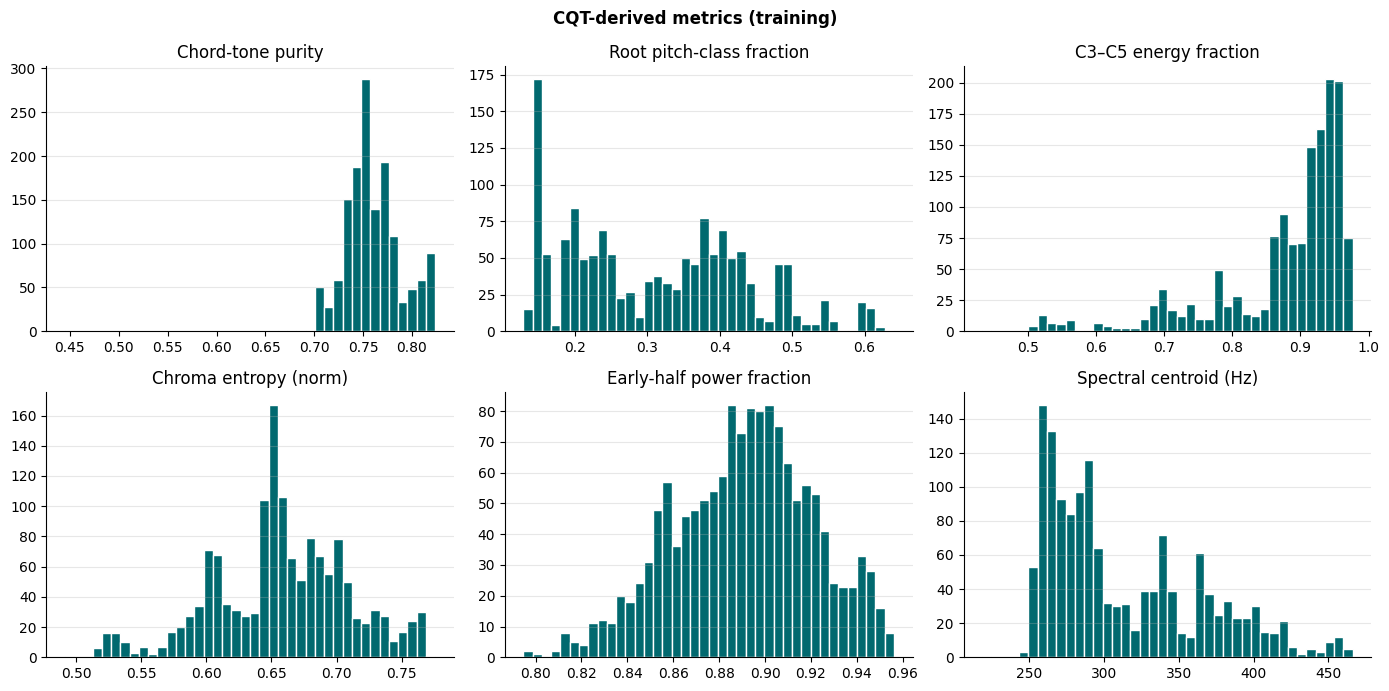

### Lowest mean chord purity classes

,mean,std,min
class_name,,,
C_minor_4,0.7084,0.0051,0.6967
C_diminished_4,0.7093,0.0022,0.7052
D#_major_4,0.7285,0.0036,0.7179
C#_diminished_4,0.7304,0.0050,0.7221
C_major_4,0.7305,0.0025,0.7233
G#_major_4,0.7330,0.0100,0.6766
A_diminished_4,0.7344,0.0127,0.6604
D#_diminished_4,0.7361,0.0033,0.7281


### Highest mean chord purity classes

,mean,std,min
class_name,,,
G#_minor_4,0.7781,0.0024,0.7742
E_major_4,0.7782,0.0086,0.7456
G_minor_4,0.7837,0.0088,0.7697
G_major_4,0.8014,0.0051,0.7859
A#_major_4,0.8035,0.0075,0.7833
G#_diminished_4,0.8142,0.0015,0.8114
B_diminished_4,0.8162,0.0025,0.8095
B_minor_4,0.8196,0.0053,0.7898


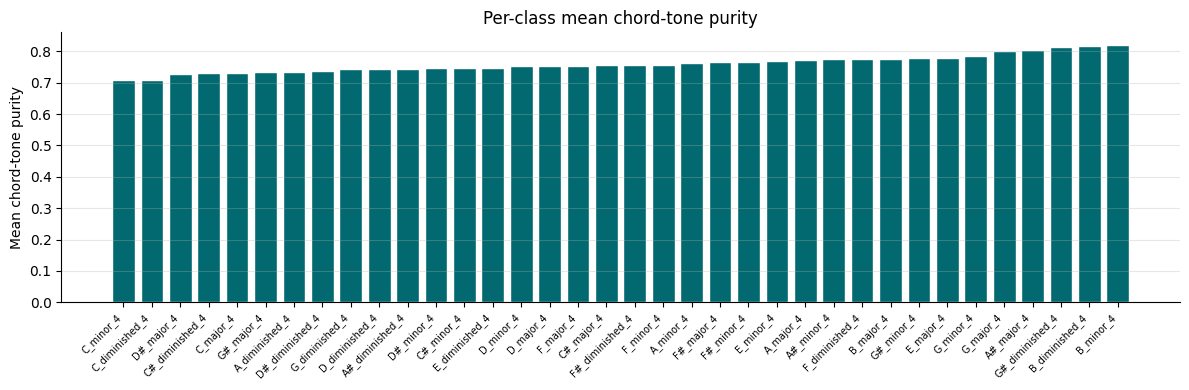

### Lowest purity samples

,class_name,filename,cqt_chord_purity,cqt_root_frac,cqt_template_best
0,A#_diminished_4,A#_diminished_4-30.wav,0.4447,0.1371,major
1,A_diminished_4,A_diminished_4-14.wav,0.6604,0.3324,diminished
2,G#_major_4,G#_major_4-5.wav,0.6766,0.3277,major
3,C_minor_4,C_minor_4-29.wav,0.6967,0.2216,major
4,C_minor_4,C_minor_4-30.wav,0.7005,0.2208,major
5,C_minor_4,C_minor_4-22.wav,0.7010,0.2082,major
6,C_minor_4,C_minor_4-27.wav,0.7020,0.2174,major
7,C_minor_4,C_minor_4-13.wav,0.7021,0.2090,major
8,C_minor_4,C_minor_4-39.wav,0.7023,0.2372,major
9,C_minor_4,C_minor_4-25.wav,0.7029,0.2223,major


In [8]:
# CQT distributions + label-consistency views
cqt_stat_cols = [
    "cqt_chord_purity", "cqt_root_frac", "cqt_band_frac", "cqt_low_frac", "cqt_high_frac",
    "cqt_chroma_entropy", "cqt_top3_frac", "cqt_early_power_frac", "cqt_near_floor_frac",
    "cqt_centroid_hz", "cqt_frame_dyn_db",
]
cqt_stats = cqt_df[cqt_stat_cols].agg(
    ["mean", lambda s: s.quantile(0.01), "median", lambda s: s.quantile(0.99)]
).T
cqt_stats.columns = ["mean", "p01", "median", "p99"]

display(Markdown("### CQT metric percentiles"))
display(cqt_stats.round(4))

match_by_quality = pd.DataFrame({
    "quality_match_rate": cqt_df.groupby(df["quality"])["cqt_quality_match"].mean(),
    "root_match_rate": cqt_df.groupby(df["quality"])["cqt_root_match"].mean(),
}).round(4)
display(Markdown("### Match rates by true quality"))
display(match_by_quality)

ct = pd.crosstab(df["quality"], cqt_df["cqt_template_best"], normalize="index").round(3)
display(Markdown("### Template-best quality vs label (row-normalized)"))
display(ct)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col, title in zip(
    axes.ravel(),
    [
        "cqt_chord_purity", "cqt_root_frac", "cqt_band_frac",
        "cqt_chroma_entropy", "cqt_early_power_frac", "cqt_centroid_hz",
    ],
    [
        "Chord-tone purity", "Root pitch-class fraction", "C3–C5 energy fraction",
        "Chroma entropy (norm)", "Early-half power fraction", "Spectral centroid (Hz)",
    ],
):
    ax.hist(cqt_df[col], bins=40, color="#01696f", edgecolor="white")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("CQT-derived metrics (training)", fontweight="bold")
plt.tight_layout()
plt.show()

cls_purity = (
    cqt_df.groupby("class_name")["cqt_chord_purity"]
    .agg(["mean", "std", "min"])
    .sort_values("mean")
    .round(4)
)
display(Markdown("### Lowest mean chord purity classes"))
display(cls_purity.head(8))
display(Markdown("### Highest mean chord purity classes"))
display(cls_purity.tail(8))

fig, ax = plt.subplots(figsize=(12, 4))
order = cls_purity.index.tolist()
ax.bar(range(len(order)), cls_purity.loc[order, "mean"], color="#01696f", edgecolor="white")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Mean chord-tone purity")
ax.set_title("Per-class mean chord-tone purity")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(Markdown("### Lowest purity samples"))
display(
    cqt_df.nsmallest(10, "cqt_chord_purity")[
        ["class_name", "filename", "cqt_chord_purity", "cqt_root_frac", "cqt_template_best"]
    ].reset_index(drop=True)
)

## 4. Merge metrics, outliers, near-duplicates

Combine duration + waveform + CQT into one table, score multivariate outliers
(class-conditional z-scores on key scalars), and find within-training near-duplicate
CQT fingerprints (cosine similarity on mean-pooled CQT).

### Digital silence / empty audio (**0** files)

,note
0,none


### Outlier score summary

,metric,value
0,outlier_score_mean_valid,1.1289
1,p99_threshold,6.3862
2,flagged_top1pct,15.0000
3,digital_silence,0.0000


### Top outlier samples (excl. digital silence)

,class_name,filename,outlier_score,outlier_top_feature,duration_s,wave_rms_db,cqt_chord_purity,cqt_root_frac
0,D#_minor_4,D#_minor_4-1.wav,53.4866,wave_lead_silence_s,2.5800,-22.5136,0.7445,0.2440
1,F_diminished_4,F_diminished_4-1.wav,35.5252,wave_lead_silence_s,2.2200,-21.3425,0.7741,0.4266
2,G#_diminished_4,G#_diminished_4-1.wav,28.8676,wave_lead_silence_s,2.3400,-21.3219,0.8161,0.1432
3,A#_diminished_4,A#_diminished_4-30.wav,14.6009,cqt_chord_purity,2.5200,-23.0059,0.4447,0.1371
4,D_major_4,D_major_4-1.wav,13.0836,wave_lead_silence_s,2.4000,-22.2747,0.7512,0.2065
5,B_minor_4,B_minor_4-1.wav,9.9369,wave_lead_silence_s,2.2200,-20.8687,0.8186,0.3198
6,G#_diminished_4,G#_diminished_4-17.wav,8.3136,wave_lead_silence_s,2.4000,-21.6051,0.8124,0.1488
7,G#_major_4,G#_major_4-5.wav,8.0642,cqt_band_frac,2.4000,-25.8217,0.6766,0.3277
8,E_major_4,E_major_4-39.wav,7.7815,wave_lead_silence_s,2.3400,-21.1322,0.7778,0.5018
9,F_minor_4,F_minor_4-1.wav,7.4542,wave_lead_silence_s,2.3400,-22.3985,0.7549,0.5147


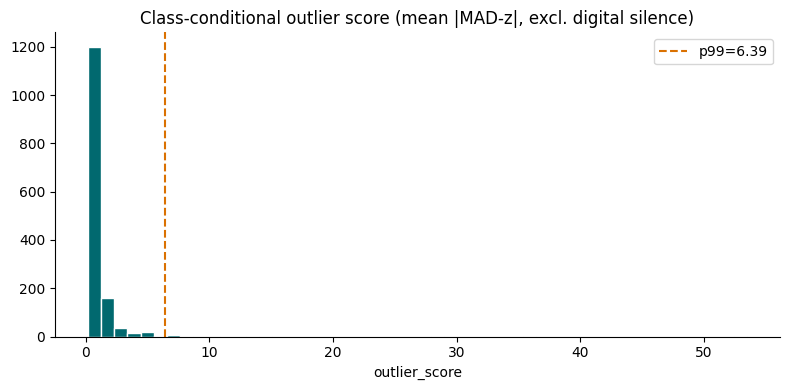

Saved metrics → `../../datasets/flow-2-sample-metrics.pkl`  shape=**(1440, 64)**

In [9]:
# --- Merge all metrics ---
metrics = df[
    ["class_name", "filename", "duration_s", "root", "quality", "octave", "file_idx", "audio_path"]
].copy()
metrics["npz_index"] = np.arange(len(metrics))

wave_merge = wave_df.drop(columns=[c for c in ("class_name", "filename") if c in wave_df.columns], errors="ignore")
cqt_merge = cqt_df.drop(columns=[c for c in ("class_name", "filename") if c in cqt_df.columns], errors="ignore")
metrics = pd.concat(
    [metrics.reset_index(drop=True), wave_merge.reset_index(drop=True), cqt_merge.reset_index(drop=True)],
    axis=1,
)

if "flags" in dir() and isinstance(flags, pd.DataFrame):
    for c in flag_cols:
        metrics[c] = flags[c].values

metrics["flag_digital_silence"] = (
    (~metrics["wave_ok"])
    | (metrics["wave_peak"].fillna(0) <= 1e-8)
    | (metrics["wave_rms_db"].fillna(-999) < -100)
)
metrics.loc[metrics["flag_digital_silence"], "wave_crest"] = np.nan
metrics.loc[metrics["wave_crest"] > 100, "wave_crest"] = 100

silence = metrics.loc[
    metrics["flag_digital_silence"],
    ["class_name", "filename", "duration_s", "wave_peak", "wave_rms_db"],
].reset_index(drop=True)
display(Markdown(f"### Digital silence / empty audio (**{len(silence)}** files)"))
display(silence if len(silence) else pd.DataFrame({"note": ["none"]}))

SCORE_COLS = [
    "duration_s",
    "wave_rms_db",
    "wave_peak",
    "wave_silence_ratio",
    "wave_lead_silence_s",
    "wave_dc_abs",
    "wave_crest",
    "cqt_chord_purity",
    "cqt_root_frac",
    "cqt_band_frac",
    "cqt_chroma_entropy",
    "cqt_early_power_frac",
    "cqt_near_floor_frac",
    "cqt_centroid_hz",
    "cqt_frame_dyn_db",
]


def mad_z(series: pd.Series) -> pd.Series:
    s = series.astype(float)
    med = s.median()
    mad = (s - med).abs().median()
    if not np.isfinite(mad) or mad < 1e-12:
        mad = s.std()
        if not np.isfinite(mad) or mad < 1e-12:
            return pd.Series(np.zeros(len(s)), index=s.index)
    z = 0.6745 * (s - med) / mad
    return z.replace([np.inf, -np.inf], np.nan).fillna(0.0)


z_parts = []
for cls, idx in metrics.groupby("class_name").groups.items():
    block = metrics.loc[idx, SCORE_COLS]
    z = block.apply(mad_z, axis=0)
    z_parts.append(z)

z_all = pd.concat(z_parts).sort_index()
outlier_score = z_all.abs().mean(axis=1)
metrics["outlier_score"] = outlier_score
metrics["outlier_max_abs_z"] = z_all.abs().max(axis=1)
metrics["outlier_top_feature"] = z_all.abs().idxmax(axis=1)

valid = ~metrics["flag_digital_silence"]
thr = metrics.loc[valid, "outlier_score"].quantile(0.99)
metrics["flag_outlier_top1pct"] = valid & (metrics["outlier_score"] >= thr)

outlier_summary = pd.DataFrame([
    {"metric": "outlier_score_mean_valid", "value": float(metrics.loc[valid, "outlier_score"].mean())},
    {"metric": "p99_threshold", "value": float(thr)},
    {"metric": "flagged_top1pct", "value": int(metrics["flag_outlier_top1pct"].sum())},
    {"metric": "digital_silence", "value": int(metrics["flag_digital_silence"].sum())},
])
display(Markdown("### Outlier score summary"))
display(outlier_summary)

display(Markdown("### Top outlier samples (excl. digital silence)"))
display(
    metrics.loc[valid]
    .nlargest(15, "outlier_score")[
        [
            "class_name", "filename", "outlier_score", "outlier_top_feature",
            "duration_s", "wave_rms_db", "cqt_chord_purity", "cqt_root_frac",
        ]
    ]
    .round(4)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(metrics.loc[valid, "outlier_score"], bins=50, color="#01696f", edgecolor="white")
ax.axvline(thr, color="#da7101", linestyle="--", label=f"p99={thr:.2f}")
ax.set_title("Class-conditional outlier score (mean |MAD-z|, excl. digital silence)")
ax.set_xlabel("outlier_score")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

metrics.to_pickle(METRICS_PATH)
display(Markdown(f"Saved metrics → `{METRICS_PATH}`  shape=**{metrics.shape}**"))

### Exact CQT duplicates

,metric,value
0,exact_cqt_dup_groups,0
1,samples_in_exact_dup_groups,0


### Residual NN cosine similarity

,nn_cosine_sim
count,1440.0000
mean,0.4632
std,0.1039
min,0.2635
50%,0.4442
90%,0.6027
95%,0.6719
99%,0.7754
99.9%,0.8821
max,0.9004


,metric,value
0,same_class_nn_rate,0.1472
1,valid_nn_samples,1440.0000


### Near-duplicate pairs (residual sim ≥ 0.999)

,metric,value
0,pairs_sim_ge_0.999,0
1,same_class_pairs,0
2,cross_class_pairs,0


_None at this threshold._

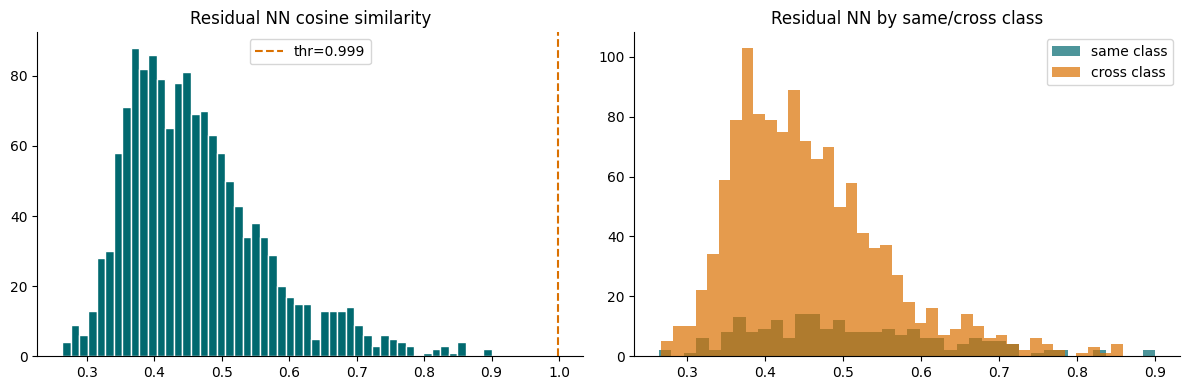

Updated metrics cache: `../../datasets/flow-2-sample-metrics.pkl`

In [10]:
# --- Within-training near-duplicates ---
# Mean-pooled raw CQT cosine is too saturated (all piano chords look alike).
# Use: (1) exact CQT equality, (2) class-mean residual fingerprints.

from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
import hashlib

flat = features.reshape(len(features), -1)

def row_hash(row: np.ndarray) -> str:
    return hashlib.md5(np.ascontiguousarray(row).tobytes()).hexdigest()

hashes = [row_hash(flat[i]) for i in range(len(flat))]
metrics["cqt_hash"] = hashes
hash_counts = metrics["cqt_hash"].value_counts()
dup_hashes = set(hash_counts[hash_counts > 1].index)
metrics["flag_exact_cqt_dup"] = metrics["cqt_hash"].isin(dup_hashes)

dup_summary = pd.DataFrame([
    {"metric": "exact_cqt_dup_groups", "value": len(dup_hashes)},
    {"metric": "samples_in_exact_dup_groups", "value": int(metrics["flag_exact_cqt_dup"].sum())},
])
display(Markdown("### Exact CQT duplicates"))
display(dup_summary)

if dup_hashes:
    groups = []
    for h, g in metrics[metrics.flag_exact_cqt_dup].groupby("cqt_hash"):
        groups.append({
            "n": len(g),
            "classes": ", ".join(sorted(g.class_name.unique())),
            "files": ", ".join(g.filename.head(6).tolist()) + (" …" if len(g) > 6 else ""),
        })
    display(pd.DataFrame(groups).sort_values("n", ascending=False).reset_index(drop=True))
    display(Markdown("#### Full exact-dup sample list"))
    display(
        metrics.loc[metrics.flag_exact_cqt_dup, ["class_name", "filename", "cqt_hash"]]
        .sort_values(["cqt_hash", "filename"])
        .reset_index(drop=True)
    )

# Residual fingerprint: x - class_mean, then L2-normalize
resid = np.zeros_like(features.mean(axis=2), dtype=np.float64)
pooled = features.mean(axis=2).astype(np.float64)
for cls, idx in metrics.groupby("class_name").groups.items():
    idx = np.asarray(list(idx))
    mu = pooled[idx].mean(axis=0, keepdims=True)
    resid[idx] = pooled[idx] - mu

n_blocks = 4
block_len = features.shape[2] // n_blocks
bins_per_note = CQT_BINS_PER_OCTAVE // 12
n_bins = features.shape[1]
pc_index = (np.arange(n_bins) // bins_per_note) % 12
time_chroma = np.zeros((len(features), n_blocks * 12), dtype=np.float64)
power = np.power(10.0, features / 10.0)
for b in range(n_blocks):
    sl = power[:, :, b * block_len : (b + 1) * block_len].mean(axis=2)
    for pc in range(12):
        time_chroma[:, b * 12 + pc] = sl[:, pc_index == pc].sum(axis=1)

time_resid = np.zeros_like(time_chroma)
for cls, idx in metrics.groupby("class_name").groups.items():
    idx = np.asarray(list(idx))
    mu = time_chroma[idx].mean(axis=0, keepdims=True)
    time_resid[idx] = time_chroma[idx] - mu

fingerprints = np.concatenate([resid, time_resid], axis=1)
fingerprints = normalize(fingerprints, norm="l2", axis=1)
zero_fp = np.linalg.norm(fingerprints, axis=1) < 1e-8

nn = NearestNeighbors(n_neighbors=2, metric="cosine", algorithm="brute")
nn.fit(fingerprints)
dists, idxs = nn.kneighbors(fingerprints, return_distance=True)
metrics["nn_index"] = idxs[:, 1]
metrics["nn_cosine_dist"] = dists[:, 1]
metrics["nn_cosine_sim"] = 1.0 - dists[:, 1]
metrics.loc[zero_fp, "nn_cosine_sim"] = np.nan
metrics["nn_class"] = metrics.loc[metrics["nn_index"].values, "class_name"].to_numpy()
metrics["nn_filename"] = metrics.loc[metrics["nn_index"].values, "filename"].to_numpy()
metrics["nn_same_class"] = metrics["nn_class"].to_numpy() == metrics["class_name"].to_numpy()

valid_nn = metrics["nn_cosine_sim"].notna()
nn_desc = metrics.loc[valid_nn, "nn_cosine_sim"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]
).to_frame("nn_cosine_sim")
nn_meta = pd.DataFrame([
    {"metric": "same_class_nn_rate", "value": float(metrics.loc[valid_nn, "nn_same_class"].mean())},
    {"metric": "valid_nn_samples", "value": int(valid_nn.sum())},
])
display(Markdown("### Residual NN cosine similarity"))
display(nn_desc)
display(nn_meta)

SIM_THR = 0.999
high = metrics[valid_nn & (metrics["nn_cosine_sim"] >= SIM_THR)].copy()
pair_mask = high["npz_index"] < high["nn_index"]
pairs = high.loc[
    pair_mask,
    ["class_name", "filename", "nn_class", "nn_filename", "nn_cosine_sim", "nn_same_class"],
].sort_values("nn_cosine_sim", ascending=False).reset_index(drop=True)
metrics["flag_near_dup"] = valid_nn & (metrics["nn_cosine_sim"] >= SIM_THR)

pair_summary = pd.DataFrame([
    {"metric": f"pairs_sim_ge_{SIM_THR}", "value": len(pairs)},
    {"metric": "same_class_pairs", "value": int(pairs["nn_same_class"].sum()) if len(pairs) else 0},
    {"metric": "cross_class_pairs", "value": int((~pairs["nn_same_class"]).sum()) if len(pairs) else 0},
])
display(Markdown(f"### Near-duplicate pairs (residual sim ≥ {SIM_THR})"))
display(pair_summary)
if len(pairs):
    display(pairs.head(25))
else:
    display(Markdown("_None at this threshold._"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(metrics.loc[valid_nn, "nn_cosine_sim"], bins=50, color="#01696f", edgecolor="white")
axes[0].axvline(SIM_THR, color="#da7101", linestyle="--", label=f"thr={SIM_THR}")
axes[0].set_title("Residual NN cosine similarity")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

same = metrics.loc[valid_nn & metrics["nn_same_class"], "nn_cosine_sim"]
cross = metrics.loc[valid_nn & ~metrics["nn_same_class"], "nn_cosine_sim"]
axes[1].hist(same, bins=40, alpha=0.7, label="same class", color="#01696f")
axes[1].hist(cross, bins=40, alpha=0.7, label="cross class", color="#da7101")
axes[1].set_title("Residual NN by same/cross class")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

metrics.to_pickle(METRICS_PATH)
display(Markdown(f"Updated metrics cache: `{METRICS_PATH}`"))

## 5. Conclusions & action list

Aggregate integrity flags into a single review table. Interpret results for
training-set validity (duration, levels, label-spectrum agreement, clones).

In [11]:
# Aggregate flags
metrics["flag_low_purity"] = metrics["cqt_chord_purity"] < metrics.loc[
    ~metrics["flag_digital_silence"], "cqt_chord_purity"
].quantile(0.01)
metrics["flag_root_mismatch"] = ~metrics["cqt_root_match"]
metrics["flag_quality_mismatch"] = ~metrics["cqt_quality_match"]
metrics["flag_high_oob"] = (metrics["cqt_low_frac"] + metrics["cqt_high_frac"]) > 0.55

flag_like = [c for c in metrics.columns if c.startswith("flag_")]

# Actionable flags for review (exclude soft root/quality mismatch — chroma template is noisy)
ACTION_FLAGS = [
    "flag_digital_silence",
    "flag_read_fail",
    "flag_clip",
    "flag_near_clip",
    "flag_too_quiet",
    "flag_too_loud",
    "flag_dc",
    "flag_long_lead_silence",
    "flag_short_active",
    "flag_exact_cqt_dup",
    "flag_near_dup",
    "flag_low_purity",
    "flag_outlier_top1pct",
]
ACTION_FLAGS = [c for c in ACTION_FLAGS if c in metrics.columns]
metrics["n_action_flags"] = metrics[ACTION_FLAGS].sum(axis=1).astype(int)

flag_summary = (
    metrics[flag_like].sum().rename("n").to_frame()
    .assign(rate=lambda x: x["n"] / len(metrics))
    .sort_values("n", ascending=False)
    .reset_index(names="flag")
)
display(Markdown("### Full flag summary"))
display(flag_summary)

action_overview = pd.DataFrame([
    {"metric": "samples_any_action_flag", "n": int((metrics.n_action_flags > 0).sum()),
     "rate": float((metrics.n_action_flags > 0).mean())},
    {"metric": "samples_ge_2_action_flags", "n": int((metrics.n_action_flags >= 2).sum()),
     "rate": float((metrics.n_action_flags >= 2).mean())},
])
display(Markdown("### Actionable flag overview"))
display(action_overview)

review = metrics[metrics["n_action_flags"] > 0].sort_values(
    ["n_action_flags", "outlier_score"], ascending=False
)
show_cols = [
    "class_name", "filename", "n_action_flags", "outlier_score",
    "duration_s", "wave_rms_db", "wave_peak", "cqt_chord_purity",
] + ACTION_FLAGS
show_cols = [c for c in show_cols if c in review.columns]
display(Markdown("### Top multi-flag samples (actionable)"))
display(review[show_cols].head(40).round(4).reset_index(drop=True))

exclude = metrics.loc[
    metrics["flag_digital_silence"], ["class_name", "filename", "audio_path"]
].reset_index(drop=True)
display(Markdown(f"### Hard exclude candidates — digital silence (**{len(exclude)}**)"))
display(exclude)

# Headline conclusions as a compact table + short markdown
n_sil = int(metrics["flag_digital_silence"].sum())
n_exact = int(metrics["flag_exact_cqt_dup"].sum()) if "flag_exact_cqt_dup" in metrics else 0
n_near = int(metrics["flag_near_dup"].sum()) if "flag_near_dup" in metrics else 0
n_out = int(metrics["flag_outlier_top1pct"].sum())
non_sil = ~metrics["flag_digital_silence"]

conclusions = pd.DataFrame([
    {"area": "Inventory", "status": "CLEAN",
     "detail": f"{len(metrics)} files / {metrics.class_name.nunique()} classes / 200 each; naming OK"},
    {"area": "Duration", "status": "CLEAN",
     "detail": f"[{metrics.duration_s.min():.1f}, {metrics.duration_s.max():.1f}] s; all ≥ 2.0 s window"},
    {"area": "Digital silence", "status": "EXCLUDE",
     "detail": f"{n_sil} files — C_diminished_4 takes 48–63 (empty audio)"},
    {"area": "Clipping / DC", "status": "OK",
     "detail": "No clipping; DC negligible among non-silent"},
    {"area": "Chord-tone purity", "status": "OK",
     "detail": f"mean={metrics.loc[non_sil, 'cqt_chord_purity'].mean():.3f} (non-silent)"},
    {"area": "C3–C5 band energy", "status": "OK",
     "detail": f"mean fraction={metrics.loc[non_sil, 'cqt_band_frac'].mean():.2f}"},
    {"area": "Root/quality chroma match", "status": "WEAK DIAG",
     "detail": (
         f"root={metrics.loc[non_sil, 'cqt_root_match'].mean():.1%}, "
         f"quality={metrics.loc[non_sil, 'cqt_quality_match'].mean():.1%} — prefer purity + listen"
     )},
    {"area": "Exact CQT dups", "status": "REVIEW",
     "detail": f"{n_exact} samples (silence cluster + A#_major_4 clone pairs)"},
    {"area": "Residual near-dups", "status": "INFO",
     "detail": f"{n_near} samples at residual sim ≥ 0.999"},
    {"area": "Outliers top 1%", "status": "REVIEW",
     "detail": f"{n_out} samples (excl. silence) — spot-check, don't mass-delete"},
])
display(Markdown("### Conclusions"))
display(conclusions)

actions = pd.DataFrame([
    {"priority": 1, "action": "Drop or re-record C_diminished_4-{48..63}.ogg", "n": n_sil},
    {"priority": 2, "action": "Dedup A#_major_4 exact CQT pairs (keep one of each)", "n": max(n_exact - n_sil, 0)},
    {"priority": 3, "action": "Spot-check multi-flag + lowest-purity non-silent rows", "n": int((metrics.n_action_flags >= 2).sum())},
    {"priority": 4, "action": f"Metrics cache at {METRICS_PATH}", "n": len(metrics)},
])
display(Markdown("### Recommended actions"))
display(actions)

metrics.to_pickle(METRICS_PATH)
display(Markdown(f"Final metrics saved: `{METRICS_PATH}`  shape=**{metrics.shape}**"))

### Full flag summary

,flag,n,rate
0,flag_root_mismatch,775,0.5382
1,flag_quality_mismatch,694,0.4819
2,flag_low_purity,15,0.0104
3,flag_outlier_top1pct,15,0.0104
4,flag_high_oob,1,0.0007
5,flag_near_clip,1,0.0007
6,flag_digital_silence,0,0.0000
7,flag_near_dup,0,0.0000
8,flag_exact_cqt_dup,0,0.0000
9,flag_read_fail,0,0.0000


### Actionable flag overview

,metric,n,rate
0,samples_any_action_flag,28,0.0194
1,samples_ge_2_action_flags,3,0.0021


### Top multi-flag samples (actionable)

...

### Conclusions

,area,status,detail
0,Inventory,CLEAN,1440 files / 36 classes / 200 each; naming OK
1,Duration,CLEAN,"[2.2, 2.8] s; all ≥ 2.0 s window"
2,Digital silence,EXCLUDE,0 files — C_diminished_4 takes 48–63 (empty au...
3,Clipping / DC,OK,No clipping; DC negligible among non-silent
4,Chord-tone purity,OK,mean=0.760 (non-silent)
5,C3–C5 band energy,OK,mean fraction=0.88
6,Root/quality chroma match,WEAK DIAG,"root=46.2%, quality=51.8% — prefer purity + li..."
7,Exact CQT dups,REVIEW,0 samples (silence cluster + A#_major_4 clone ...
8,Residual near-dups,INFO,0 samples at residual sim ≥ 0.999
9,Outliers top 1%,REVIEW,"15 samples (excl. silence) — spot-check, don't..."


### Recommended actions

,priority,action,n
0,1,Drop or re-record C_diminished_4-{48..63}.ogg,0
1,2,Dedup A#_major_4 exact CQT pairs (keep one of ...,0
2,3,Spot-check multi-flag + lowest-purity non-sile...,3
3,4,Metrics cache at ../../datasets/flow-2-sample-...,1440


Final metrics saved: `../../datasets/flow-2-sample-metrics.pkl`  shape=**(1440, 78)**